In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

Zad 1

In [245]:
def euclidean_length(X, C):
    result = np.empty((X.shape[0], C.shape[0]))
    for i, x in enumerate(X):
        for j, y in enumerate(C):
            diff = x - y
            result[i, j] = np.sqrt(np.dot(diff, diff))
    return result

def mahalanobis_distance(X, C):
    matrix_cov = np.cov(X.T)
    matrix_cov_inv = np.linalg.inv(matrix_cov)
    results = np.zeros((X.shape[0], C.shape[0]))

    for i, a in enumerate(X):
        for j, b in enumerate(C):
            diff = a - b
            results[i, j] = np.sqrt(np.dot(np.dot(diff, matrix_cov_inv), diff.T))
    return results

In [246]:
def k_srodki(data, K):
    n_examples = data.shape[0]
    srodki = data[np.random.choice(n_examples, K, replace=False)]
    przypisania = np.full(n_examples, -1)

    for iteracja in range(1000):
        lengths = euclidean_length(data, srodki)
        new_przypisania = np.argmin(lengths, axis=1)

        #if np.array_equal(przypisania, new_przypisania):
        #    break

        przypisania = new_przypisania.copy()

        for i in range(K):
            elementy = data[przypisania == i]
            if len(elementy) > 0:
                srodki[i] = np.mean(elementy, axis=0)
    print(iteracja)
    return srodki, przypisania

999


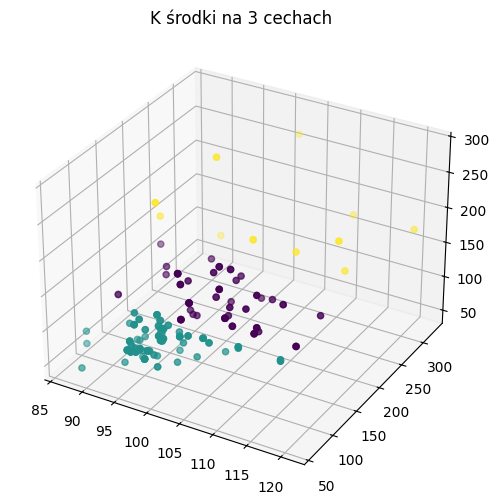

In [247]:
datas = pd.read_csv("autos.csv")

wybrane_cechy_3 = ['wheel-base', 'engine-size', 'horsepower']
macierz_3 = datas[wybrane_cechy_3].dropna().values
centra3, klasy3 = k_srodki(macierz_3, 3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(macierz_3[:, 0], macierz_3[:, 1], macierz_3[:, 2], c=klasy3)
ax.set_title("K środki na 3 cechach")
plt.show()

Zad 2

999


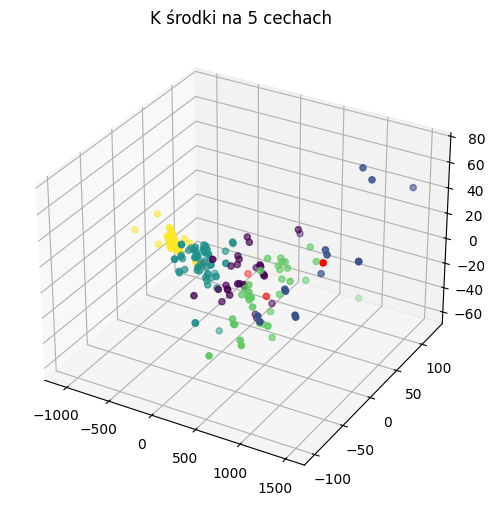

In [248]:
wybrane_cechy_5 = ['wheel-base', 'curb-weight', 'city-mpg', 'engine-size', 'horsepower']
macierz_5 = datas[wybrane_cechy_5].dropna().values
centra5, klasy5 = k_srodki(macierz_5, 5)

#macierz_5_PCA = PCA(n_components=2).fit_transform(macierz_5)
pca = PCA(n_components=3)
macierz_5_PCA = pca.fit_transform(macierz_5)
srodki_5_PCA = pca.transform(centra5)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(macierz_5_PCA[:, 0], macierz_5_PCA[:, 1], macierz_5_PCA[:, 2], c=klasy5)
ax.scatter(srodki_5_PCA[:, 0], srodki_5_PCA[:, 1], srodki_5_PCA[:, 2], c='red')
ax.set_title("K środki na 5 cechach")
ax.grid(True)
plt.show()